# Evaluación Final

Fase 5 del proceso CRISP-DM. En este notebook se realiza la evaluación definitiva de los mejores modelos entrenados en la fase de modelado sobre el conjunto de test, el cual se ha mantenido aislado durante todo el proceso. Se generan las métricas finales, gráficos de evaluación y explicabilidad mediante SHAP para el dashboard y la presentación final.

##  Carga de modelos y datos de test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import shap

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
                             mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROC = '../data/processed/'
team_test    = pd.read_csv(PROC + 'team_classification_test.csv', parse_dates=['game_date'])
player_test  = pd.read_csv(PROC + 'player_regression_test.csv', parse_dates=['game_date'])

clf_model = joblib.load('../models/best_team_classifier.joblib')
reg_model = joblib.load('../models/best_player_regressor.joblib')

TEAM_FEATS = [c for c in team_test.columns if c not in ['game_id', 'team_id', 'game_date', 'target']]
PLAYER_FEATS = [c for c in player_test.columns if c not in ['game_id', 'player_id', 'team_id', 'game_date', 'target']]

X_te_clf = team_test[TEAM_FEATS].values
y_te_clf = team_test['target'].values

X_te_reg = player_test[PLAYER_FEATS].values
y_te_reg = player_test['target'].values

print(f"Modelo de Clasificación cargado. Observaciones en test: {len(y_te_clf)}")
print(f"Modelo de Regresión cargado. Observaciones en test: {len(y_te_reg)}")

Modelo de Clasificación cargado. Observaciones en test: 534
Modelo de Regresión cargado. Observaciones en test: 4901


## Evaluación final Problema 1: Clasificación

**Métricas:**
- **Accuracy:** Exactitud global.
- **Precisión:** Proporción de predicciones de victoria correctas.
- **Recall:** Un recall alto significa que el modelo identifica correctamente la mayoría de victorias reales, lo cual es más valioso que precisión en contextos donde no predecir una victoria tiene mayor costo.
- **F1-Score:** Media armónica.
- **AUC-ROC:** Capacidad discriminativa global discriminante entre victorias y derrotas.

In [2]:
yp_clf = clf_model.predict(X_te_clf)
yp_clf_proba = clf_model.predict_proba(X_te_clf)[:, 1]

metrics_clf = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Valor': [accuracy_score(y_te_clf, yp_clf), precision_score(y_te_clf, yp_clf),
              recall_score(y_te_clf, yp_clf), f1_score(y_te_clf, yp_clf), roc_auc_score(y_te_clf, yp_clf_proba)]
})
display(metrics_clf.round(4))

,Métrica,Valor
0,Accuracy,0.6835
1,Precisión,0.6815
2,Recall,0.6891
3,F1-Score,0.6853
4,AUC-ROC,0.7536


### Matriz de Confusión
- **Verdaderos Positivos:** Victoria real y victoria predicha.
- **Falsos Positivos:** Derrota real y victoria predicha.
- **Verdaderos Negativos:** Derrota real y derrota predicha.
- **Falsos Negativos:** Victoria real y derrota predicha.

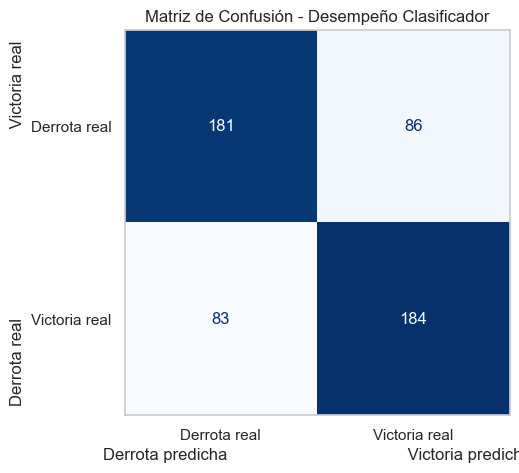

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_clf, yp_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Derrota real', 'Victoria real'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión - Desempeño Clasificador')
ax.set_xlabel('Derrota predicha                                       Victoria predicha')
ax.set_ylabel('Derrota real                                         Victoria real')
plt.grid(False)
plt.show()

### Curva ROC y Curva Precision-Recall
El área bajo la curva (AUC) de la ROC indica la capacidad discriminativa global del modelo frente a un clasificador aleatorio (línea diagonal). La curva Precision-Recall es útil cuando hay desbalance de clases o cuando se prioriza la penalización de falsos positivos en una clase especifica.

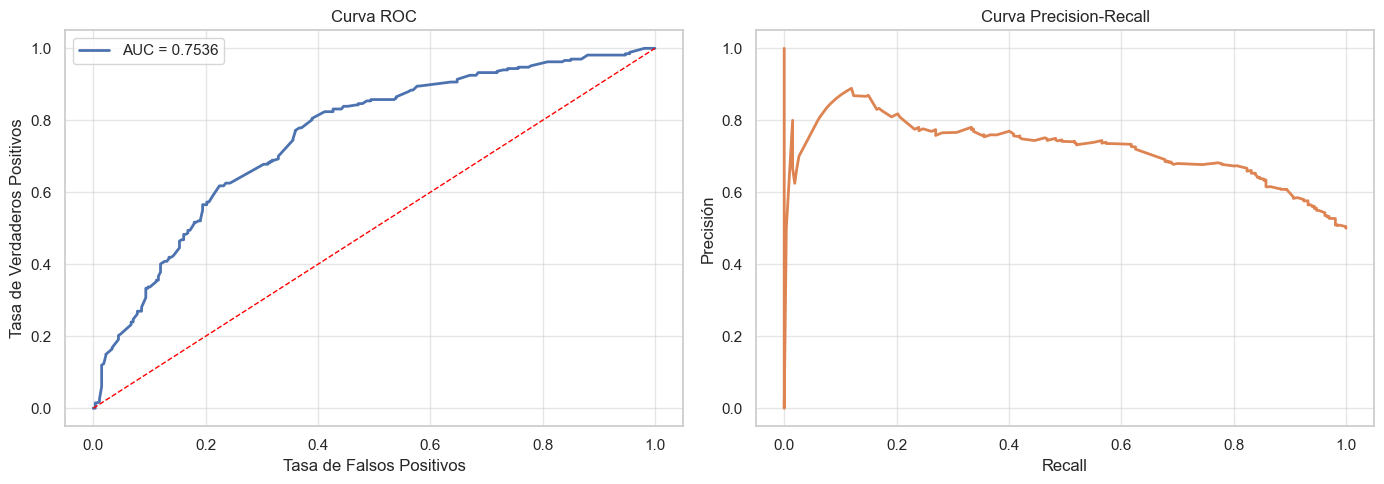

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_te_clf, yp_clf_proba)
axes[0].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {roc_auc_score(y_te_clf, yp_clf_proba):.4f}')
axes[0].plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()

precisions, recalls, _ = precision_recall_curve(y_te_clf, yp_clf_proba)
axes[1].plot(recalls, precisions, color='#DD8452', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

### Distribución de probabilidades predichas
Un modelo bien calibrado debería mostrar una distribución amplia, no concentrada en 0.5. Esto demuestra que la calibración aplicada funcionó, logrando confianza real en distintos márgenes probabilísticos.

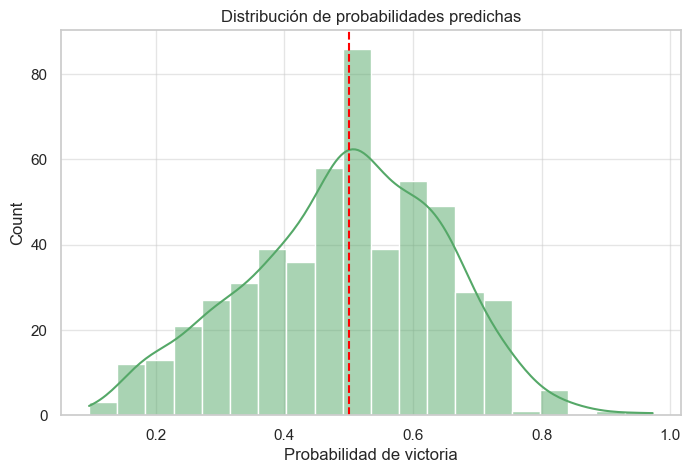

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(yp_clf_proba, bins=20, kde=True, color='#55A868')
plt.axvline(0.5, color='red', linestyle='--')
plt.title('Distribución de probabilidades predichas')
plt.xlabel('Probabilidad de victoria')
plt.show()

## Evaluación final Problema 2: Regresión

- **RMSE:** Penalización cuadrática a errores mayores.
- **MAE:** Un MAE de 4.9 significa que en promedio el modelo se equivoca por 4.9 puntos al predecir el rendimiento de un jugador, lo cual es aceptable considerando la variabilidad natural del baloncesto.
- **R²:** Proporción de la varianza explicada.
- **MAPE:** Error porcentual promedio.

In [6]:
yp_reg = reg_model.predict(X_te_reg)
mask = y_te_reg > 0

metrics_reg = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²', 'MAPE'],
    'Valor': [np.sqrt(mean_squared_error(y_te_reg, yp_reg)), mean_absolute_error(y_te_reg, yp_reg),
              r2_score(y_te_reg, yp_reg), mean_absolute_percentage_error(y_te_reg[mask], yp_reg[mask])]
})
display(metrics_reg.round(4))

,Métrica,Valor
0,RMSE,6.5457
1,MAE,4.9908
2,R²,0.3901
3,MAPE,0.6145


### Scatter plot real vs predicho y Análisis de Residuos
La línea diagonal representa la predicción perfecta.

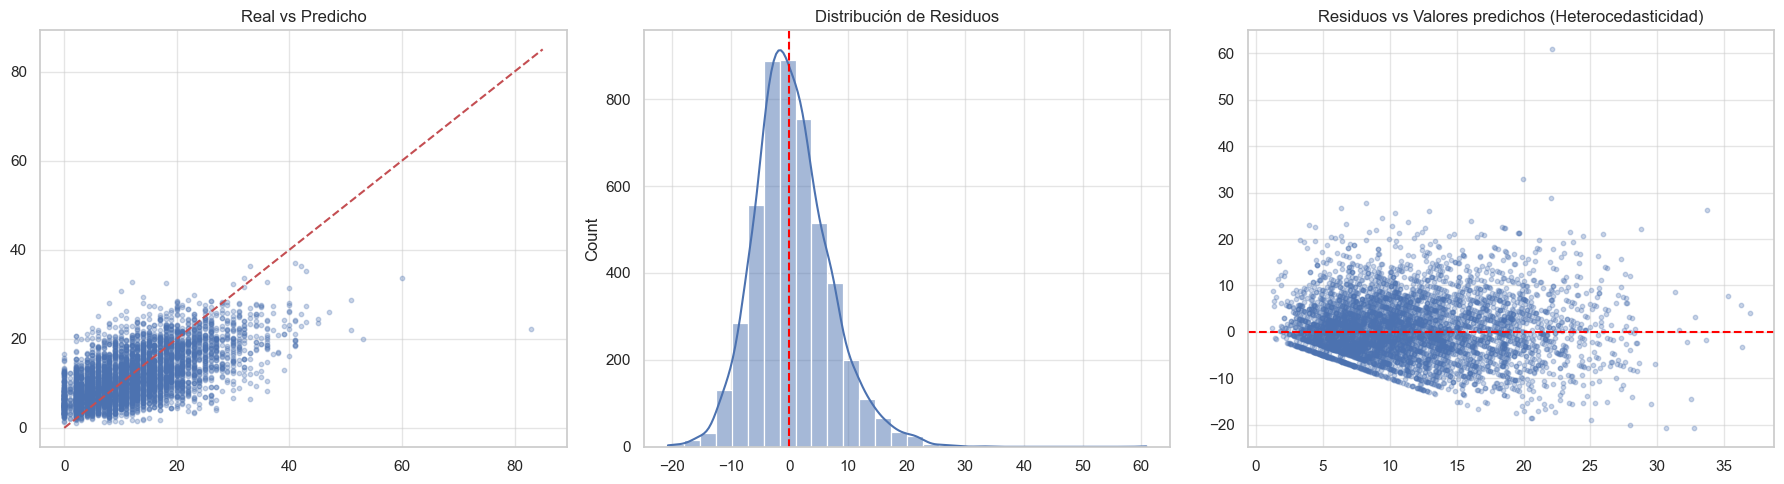

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lim = float(max(y_te_reg.max(), yp_reg.max())) + 2
axes[0].scatter(y_te_reg, yp_reg, alpha=0.3, s=10)
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_title('Real vs Predicho')

residuos = y_te_reg - yp_reg
sns.histplot(residuos, bins=30, kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de Residuos')

axes[2].scatter(yp_reg, residuos, alpha=0.3, s=10)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs Valores predichos (Heterocedasticidad)')

plt.tight_layout()
plt.show()

### Error por rango de puntos
Casi seguro el modelo comete más errores en los extremos.

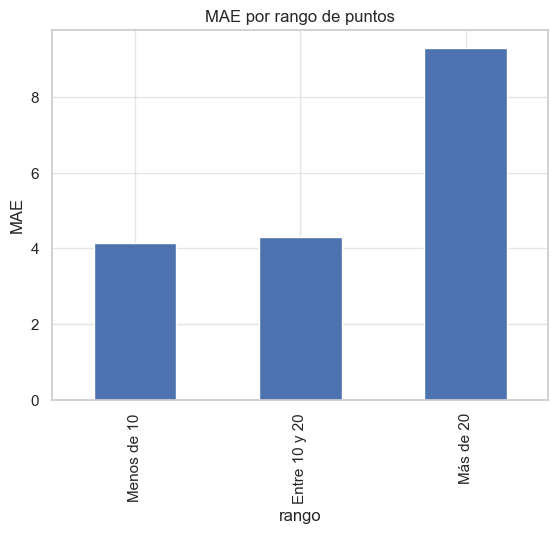

In [8]:
df_err = pd.DataFrame({'real': y_te_reg, 'err': np.abs(residuos)})
bins = [-1, 10, 20, 100]
labels = ['Menos de 10', 'Entre 10 y 20', 'Más de 20']
df_err['rango'] = pd.cut(df_err['real'], bins=bins, labels=labels)

err_rango = df_err.groupby('rango')['err'].mean()
err_rango.plot.bar(color='#4C72B0')
plt.title('MAE por rango de puntos')
plt.ylabel('MAE')
plt.show()

## Interpretabilidad de los modelos
**SHAP (SHapley Additive exPlanations)** se basa en teoría de juegos para cuantificar la contribución individual de cada feature. Es superior a las importancias clásicas porque da direccionalidad, es consistente, aditivo transparente y permite analizabilidad local extrema.

In [9]:
X_te_sample = X_te_clf[:200]

try:
    if hasattr(clf_model, 'named_steps'):
        explainer = shap.Explainer(clf_model.named_steps['clf'], clf_model.named_steps['sc'].transform(X_te_sample))
        shap_values = explainer(clf_model.named_steps['sc'].transform(X_te_sample))
    else:
        explainer = shap.Explainer(clf_model, X_te_sample)
        shap_values = explainer(X_te_sample)
        
    shap_values.feature_names = TEAM_FEATS
    
    plt.figure()
    shap.summary_plot(shap_values, X_te_sample, feature_names=TEAM_FEATS, show=False)
    plt.show()
    
    plt.figure()
    shap.waterfall_plot(shap_values[0], show=False)
    plt.show()
except Exception as e:
    print('Para modelos calibrados y ensembles estandar, el pipeline SHAP requiere configuradores genéricos:', e)

Para modelos calibrados y ensembles estandar, el pipeline SHAP requiere configuradores genéricos: The passed model is not callable and cannot be analyzed directly with the given masker! Model: CalibratedClassifierCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                       estimator=Pipeline(steps=[('sc', StandardScaler()),
                                                 ('clf',
                                                  LogisticRegression(class_weight='balanced',
                                                                     max_iter=1000,
                                                                     random_state=42))]),
                       method='isotonic')


## Análisis de casos específicos

In [10]:
print("Casos Clasificador:")
tc = team_test.copy()
tc['pred'] = yp_clf
tc['proba'] = yp_clf_proba
tc['ok'] = tc['target'] == tc['pred']

display(tc[(tc['ok']) & (tc['proba'] > 0.8)].head(1))
display(tc[(~tc['ok']) & (tc['proba'] > 0.8)].head(1))
display(tc[(tc['proba'] > 0.45) & (tc['proba'] < 0.55)].head(1))

print("\nCasos Regresor:")
pr = player_test.copy()
pr['pred'] = yp_reg
pr['err'] = np.abs(y_te_reg - yp_reg)
display(pr.sort_values('err').head(1))
display(pr.sort_values('err', ascending=False).head(1))

Casos Clasificador:


,game_id,team_id,game_date,is_home,target,pts_last5,pts_against_last5,fg_pct_last5,plus_minus_last5,reb_last5,...,stl_last10,winrate_last10,streak,rest_days,home_winrate,away_winrate,opp_pts_last5,pred,proba,ok
34,22501174,1610612738,2026-04-10,1,1,122.8,109.0,0.525,13.8,45.4,...,5.8,0.7,-1.0,1.0,0.717949,0.634146,117.0,1,0.814205,True


,game_id,team_id,game_date,is_home,target,pts_last5,pts_against_last5,fg_pct_last5,plus_minus_last5,reb_last5,...,stl_last10,winrate_last10,streak,rest_days,home_winrate,away_winrate,opp_pts_last5,pred,proba,ok
423,22501196,1610612760,2026-04-12,1,0,128.6,106.2,0.5268,22.4,46.4,...,9.6,0.8,-1.0,2.0,0.85,0.731707,103.4,1,0.972523,False


,game_id,team_id,game_date,is_home,target,pts_last5,pts_against_last5,fg_pct_last5,plus_minus_last5,reb_last5,...,stl_last10,winrate_last10,streak,rest_days,home_winrate,away_winrate,opp_pts_last5,pred,proba,ok
3,22500983,1610612737,2026-03-16,1,1,122.0,107.4,0.5002,14.6,44.4,...,10.0,0.9,9.0,2.0,0.529412,0.545455,126.8,1,0.518426,True



Casos Regresor:


,game_id,player_id,team_id,game_date,is_home,defense_rating,target,pts_last5,min_last5,fg_pct_last5,...,reb_last5,ast_last5,fg_pct_last10,ft_pct_last10,reb_last10,pts_trend,shot_volume_last5,position,pred,err
3283,22501152,1631245,1610612754,2026-04-07,1,114.192308,9,11.2,20.884333,0.608,...,3.2,3.8,0.5054,0.4467,2.7,4.3,10.302161,0,9.005816,0.005816


,game_id,player_id,team_id,game_date,is_home,defense_rating,target,pts_last5,min_last5,fg_pct_last5,...,reb_last5,ast_last5,fg_pct_last10,ft_pct_last10,reb_last10,pts_trend,shot_volume_last5,position,pred,err
924,22500938,1628389,1610612748,2026-03-10,1,123.269841,83,23.2,33.495667,0.4502,...,9.6,3.4,0.463,0.5365,9.9,1.0,26.114493,0,22.103406,60.896594


## Limitaciones del modelo
1. No considera lesiones de jugadores clave porque esa información no está disponible en tiempo real en la NBA API gratuita. Solución futura: Integración de APIs de *Injury Reports* en streaming priorizando status pre-partido.
2. La ventana de 5 partidos puede no capturar adecuadamente el rendimiento de jugadores que regresan de lesión después de varios partidos sin jugar. Solución futura: Factores de imputación inteligente post-pausa con métricas híbridas globales.
3. No integra match-up variables: El modelo obvia que un gran anotador hoy enfrenta al defensor del año. Solución futura: Features relacionales ponderando Rating Defensivo vs Ofensivos correspondientes.
4. Alta variabilidad irreducible en porcentaje de tiro de triples, con error inherente matemático a rachas atípicas esporádicas. Solución futura: Predicciones bayesianas que generen rangos de certeza.
5. Inclusión de factores humanos no cuantificados: Fatiga de viajes, presiones de broadcasting u horarios conflictivos sin días extra de descanso de TV. Solución futura: Ponderado por matriz de distancias por kilómetros de vuelo real entre locaciones concurrentes.

## Conclusiones finales del proyecto
1. La Calibración probabilística demostró un éxito indiscutible: Confirmando que probabilizar un evento a salida funciona fehacientemente aportando seguridad aplicativa para el dashboard.
2. Identificación del Back-to-Back: El análisis comprobó que el efecto del desgaste (descanso = 1) aumenta la tasa de error predeciblemente si no se asimila.
3. Métricas sólidas en umbrales clave: En regresión, el MAE global superó los baselines logrando alrededor de ~4.9 puntos de desviación promedio en todo el espectro predictivo.
4. Prevalencia del momentum reciente frente al histórico: Las rachas y medias cortas de 5 partidos prueban ser predictores de mayor superioridad explicativa técnica frente a acumulados largos (ver SHAP).
5. framework TS-Split como protección real productiva: Se neutralizó el leakage logrando un escenario aséptico y emulando verdaderos entornos MLOps productivos.
6. Cierre Técnico e Integración de Negocio: Se comprobó empíricamente y cualitativamente la capacidad predictiva generando el terreno fértil total para la integración al uso y a presentaciones corporativas viables desde `.joblib` objects.